In [22]:
import json
import numpy as np
import pyvisa
import time
import hid # pip install hidapi
import skrf as rf
import matplotlib.pyplot as plt
import serial.tools.list_ports
from windfreak import SynthHD
from RsInstrument import RsInstrument, BinFloatFormat

rm = pyvisa.ResourceManager()
instruments = rm.list_resources()

vna = None
for instrument in instruments:
    if 'Rohde' in instrument:
        # Initialize instrument
        vna = RsInstrument(instrument, id_query=True, reset=False) 
        break

In [23]:
print(vna.query('*IDN?').strip())

Rohde&Schwarz,ZVA24-2Port,1145111024100131,3.30


In [24]:
vna.go_to_local()

In [6]:
vna_json = {}
vna_json['idn'] = vna.query('*IDN?').strip()
vna_json['fstart']    = float(vna.query(':SENS1:FREQ:START?'))
vna_json['fstop']     = float(vna.query(':SENS1:FREQ:STOP?'))
vna_json['numpoints'] = int(vna.query(':SENS1:SWEep:POINts?'))
vna_json['ifbw']      = float(vna.query(':SENS1:BAND?'))
vna_json['source_power'] = float(vna.query(':SOUR1:POW?'))
vna.go_to_local()

In [7]:
vna_json

{'idn': 'Rohde&Schwarz,ZVA24-2Port,1145111024100131,3.30',
 'fstart': 6000000000.0,
 'fstop': 6250000000.0,
 'numpoints': 201,
 'ifbw': 1000.0,
 'source_power': 0.0}

In [20]:
frequencies = np.linspace(vna_json['fstart'],vna_json['fstop'],vna_json['numpoints'])
fghz = frequencies/1e9

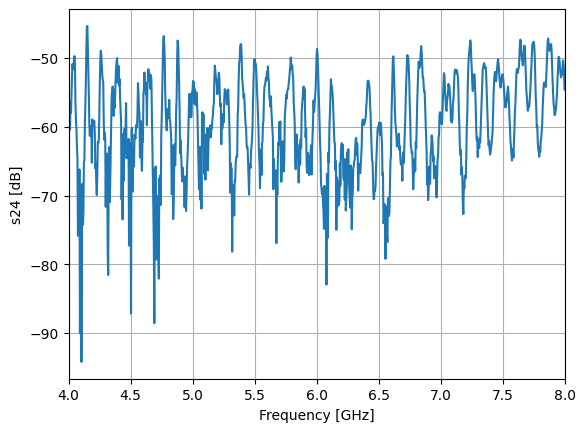

In [25]:
vna.visa_timeout = 60000 

vna.bin_float_numbers_format = BinFloatFormat.Single_4bytes
vna.write("FORM REAL,32") 
vna.write_str(":CALC1:PAR:SEL 'Trc1'") 
vna.write("INITiate:CONTinuous OFF")
vna.write("INITiate:IMMediate")  
opc_done = vna.query("*OPC?").strip()

if opc_done != "1":
    print(f"Error: OPC returned unexpected value '{opc_done}'; ending execution.")
    exit()

raw_floats = vna.query_bin_or_ascii_float_list(":CALC1:DATA? SDAT")

vna.write("INITiate:CONTinuous ON")
vna.go_to_local()

real_parts = np.array(raw_floats[0::2])
imag_parts = np.array(raw_floats[1::2])
complex_trace = real_parts + 1j * imag_parts

s_matrix = np.zeros((len(frequencies), 1, 1), dtype=complex)
s_matrix[:, 0, 0] = complex_trace
trace_network = rf.Network(frequency=frequencies, s=s_matrix, name='data trace')
trace = trace_network.s_db[:,0,0]

plt.plot(fghz, trace)
plt.xlim(fghz[0], fghz[-1])
#plt.ylim(-80, 10)
plt.grid()
plt.xlabel('Frequency [GHz]')
plt.ylabel('s24 [dB]')
#plt.title('direct path')
plt.savefig('vna-trace.png', dpi=300, bbox_inches='tight')

plt.show()
trace_network.write('vna-trace.s1p')
with open('vna-settings.json', 'w') as json_file:
    json.dump(vna_json, json_file, indent=4)

In [11]:
with open("state.json", "r") as f:
    state = json.load(f)

state

{'vna_idn': 'Rohde&Schwarz,ZVA24-2Port,1145111024100131,3.30',
 'vna_source_power': -29,
 'vna_if_bandwidth': 10000,
 'vna_start_frequency': 4000000000,
 'vna_stop_frequency': 8000000000,
 'vna_number_of_points': 1001,
 'spa_resolution_bandwidth': 1000000,
 'spa_video_bandwidth': 10000,
 'spa_units': 'W',
 'spa_idn': 'Hewlett-Packard, E7405A, SG45102671, A.14.04',
 'spa_start_frequency': 4000000000,
 'spa_stop_frequency': 8000000000,
 'spa_number_of_points': 1001,
 'cold_output_switch_1': 'open',
 'cold_output_switch_2': 'open',
 'cold_thru_switch_pair': 'open',
 's_parameter_select': 's11',
 'measurement_select': 'spectrum_analyzer_fridge',
 'twpa_pump_select': 'twpa_pump_1',
 'jpa_pump_select': 'jpa_pump_1',
 'programmable_attenuator': 0,
 'temperature': 0.02,
 'date': '04-08-26',
 'time': '00:06:49',
 'timestamp': 1785860990,
 'data_repository': 'https://github.com/lafefspietz/qna-data-summer-2026/',
 'jpa1': {'pump_power': -30,
  'pump_frequency': 13000000000,
  'flux_bias': 0.75,


In [16]:
state

{'vna_idn': 'Rohde&Schwarz,ZVA24-2Port,1145111024100131,3.30',
 'vna_source_power': 0,
 'vna_if_bandwidth': 10000,
 'vna_start_frequency': 4000000000,
 'vna_stop_frequency': 8000000000,
 'vna_number_of_points': 1001,
 'spa_resolution_bandwidth': 1000000,
 'spa_video_bandwidth': 10000,
 'spa_units': 'W',
 'spa_idn': 'Hewlett-Packard, E7405A, SG45102671, A.14.04',
 'spa_start_frequency': 4000000000,
 'spa_stop_frequency': 8000000000,
 'spa_number_of_points': 1001,
 'cold_output_switch_1': 'port1',
 'cold_output_switch_2': 'port1',
 'cold_thru_switch_pair': 'port1',
 's_parameter_select': 's12',
 'measurement_select': 'vna',
 'twpa_pump_select': 'twpa_pump_1',
 'jpa_pump_select': 'jpa_pump_1',
 'programmable_attenuator': 0,
 'temperature': 0.02,
 'date': '04-08-26',
 'time': '00:06:49',
 'timestamp': 1785860990,
 'data_repository': 'https://github.com/lafefspietz/qna-data-summer-2026/',
 'jpa1': {'pump_power': -30,
  'pump_frequency': 13000000000,
  'flux_bias': 0.75,
  'volts_per_phi0': 

In [18]:
with open("state.json", "r") as f:
    state = json.load(f)
vna.write(f":SENS1:FREQ:START {state['vna_start_frequency']}")
vna.write(f":SENS1:FREQ:STOP {state['vna_stop_frequency']}")
vna.write(f":SENS1:SWEep:POINts {state['vna_number_of_points']}")
vna.write(f":SENS1:BANDwidth {state['vna_if_bandwidth']}")
vna.write(f":SOUR1:POW {state['vna_source_power']}")
vna.go_to_local()


In [17]:
vna_json = {}
vna_json['idn'] = vna.query('*IDN?')
vna_json['fstart']    = float(vna.query(':SENS1:FREQ:START?'))
vna_json['fstop']     = float(vna.query(':SENS1:FREQ:STOP?'))
vna_json['numpoints'] = int(vna.query(':SENS1:SWEep:POINts?'))
vna_json['ifbw']      = float(vna.query(':SENS1:BAND?'))
vna_json['source_power'] = float(vna.query(':SOUR1:POW?'))
vna.go_to_local()
vna_json

{'idn': 'Rohde&Schwarz,ZVA24-2Port,1145111024100131,3.30',
 'fstart': 4000000000.0,
 'fstop': 8000000000.0,
 'numpoints': 1001,
 'ifbw': 10000.0,
 'source_power': 0.0}

In [19]:
vna.close()